<p align="center">
    <img src="https://github.com/Empa-Electronics/Tiremo-Accelerator-Workshops-AIoT/blob/master/Additionals/Empa-Accelerator-Workshops-Template-Banner.png?raw=true" alt="Tiremo® Accelerator Workshops" 
    style="display: block; margin: 0 auto"
    size="75%"
    />
</p>

# Tiremo® Accelerator Workshops'a Hoş Geldiniz!

Empa Electronics tarafından düzenlenen Tiremo® Accelerator Workshops etkinliğine hoş geldiniz. Bu açık kaynaklı repository, workshop etkinliğimizde deneyimleyeceğiniz "Tiremo®Cortex İçin Edge-AI Çözümleri Geliştirme" uygulaması çalışma ortamını edinebilmeniz ve aktivitelere kolaylıkla eşlik edebilmeniz için sizinle paylaşılmıştır.

Bu script, bir uçta yapay zeka çözümünün geliştirilme adımlarının gösterimi için oluşturulmuştur.

**Uygulama Adımları:**

1. Gereksinimlerin Dahil Edilmesi (Requirements)

2. Veri Ön-İşleme

3. Yapay Zeka Modeli Oluşturma

4. Model Eğitimi & Çözüm Geliştirme (Development)

5. Modeli Dışa Aktarma & Dağıtım (Deployment)

## 0. Kurulum (Bulut Çalışma Ortamı)
Bu başlık, bulut çalışma ortamı için gerekli kurulumların otomatik olarak yapılması için oluşturulmuştur.  
Kurulum başlığı altındaki kod hücrelerini **YALNIZCA** Google Colab ortamı için çalıştırınız.

1. Python versiyonu olarak tercih edilen 3.10 versiyonunun kurulu olduğunu teyit ediniz.

In [1]:
!python3 --version

Python 3.11.14


2. Gerekli klasör ve kaynak dosyalarını oluşturunuz/indiriniz.

In [ ]:
# !mkdir -p Datasets && mkdir -p Models

# !wget https://raw.githubusercontent.com/Empa-Electronics/Tiremo-Accelerator-Workshops-AIoT/refs/heads/master/Activity2_EdgeAI_Solutions_and_Deployment/Datasets/Dataset_HMR_3Axis_EmpaElectronics.csv -O Datasets/Dataset_HMR_3Axis_EmpaElectronics.csv

3. Gerekli Python modüllerini edininiz. Bu hücrenin ilk çalıştırılması sonrasında "Restart Session" yaparak Colab Runtime'ı güncelleyiniz.

In [3]:
# !pip3 install -r https://raw.githubusercontent.com/Empa-Electronics/Tiremo-Accelerator-Workshops-AIoT/refs/heads/master/Activity2_EdgeAI_Solutions_and_Deployment/requirements.txt

## 1. Gereksinimlerin Dahil Edilmesi

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import floor
from scipy.stats import mode

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

import optuna
import emlearn

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

/Users/mertyilmaz/CODEWORKS/WORKSHOPS/Tiremo-Accelerator-Workshops-AIoT/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# dataset path
# path_dataset = "./Datasets/Dataset_HMR_6Axis_EmpaElectronics.csv"
path_dataset = "./Datasets/Dataset_HMR_3Axis_EmpaElectronics.csv"
# class ID to class name mapping
classes = {0: "CIRCLE",
           1: "HORIZONTAL",
           2: "STANDBY",
           3: "TRIANGLE",
           4: "VERTICAL"}

## 2. Veri Ön-İşleme
### 2.1. Ham Veri Eldesi

In [6]:
df_dataset = pd.read_csv(path_dataset)
df_dataset

,acc_x,acc_y,acc_z,class
0,68,1308,-151,0
1,-153,1317,-167,0
2,-446,1300,-78,0
3,-597,1316,72,0
4,-618,1377,246,0
...,...,...,...,...
450043,31,168,-978,2
450044,31,168,-978,2
450045,31,169,-978,2
450046,29,169,-977,2


### 2.2. "Feature" & "Labels" Ayrıştırımı

In [7]:
df_feats, df_labels = df_dataset.drop(columns=["class"]), pd.DataFrame(df_dataset["class"])

Veri seti "feature" sütunları:

In [8]:
df_feats

,acc_x,acc_y,acc_z
0,68,1308,-151
1,-153,1317,-167
2,-446,1300,-78
3,-597,1316,72
4,-618,1377,246
...,...,...,...
450043,31,168,-978
450044,31,168,-978
450045,31,169,-978
450046,29,169,-977


Hedef cihazdaki IMU yönelimine uyması için sütun sırasını "acc_y", "acc_x", "acc_z" olarak değiştirin:

In [10]:
df_feats = df_feats[["acc_y", "acc_x", "acc_z"]]
df_feats

,acc_y,acc_x,acc_z
0,1308,68,-151
1,1317,-153,-167
2,1300,-446,-78
3,1316,-597,72
4,1377,-618,246
...,...,...,...
450043,168,31,-978
450044,168,31,-978
450045,169,31,-978
450046,169,29,-977


Veri seti "label" sütunu:

In [11]:
df_labels

,class
0,0
1,0
2,0
3,0
4,0
...,...
450043,2
450044,2
450045,2
450046,2


Feature ve Label dataframe yapıları için "null" değer kontrolü:

In [12]:
print(f"[features] Number of NAs: {df_feats.isna().sum().sum()}")
print(f"[features] Number of nulls: {df_feats.isnull().sum().sum()}")
print(f"[labels] Number of NAs: {df_labels.isna().sum().sum()}")
print(f"[labels] Number of nulls: {df_labels.isnull().sum().item()}")

[features] Number of NAs: 0
[features] Number of nulls: 0
[labels] Number of NAs: 0
[labels] Number of nulls: 0


Veri seti sınıflarının listesi:

In [13]:
list_categories = np.array(sorted(set(df_labels.to_numpy().flatten()))).reshape(-1, 1)
list_categories

array([[0],
       [1],
       [2],
       [3],
       [4]])

### 2.4. Veri Setinden Sekans Paketleri (Sequence Batchs) Oluşturulması
Sabit bir sekans uzunluğu (sequence lenght) ve örtüşme oranı (overlapping ratio) tanımlaması:  
  
Sekans uzunluğu, bir tablo veri seti içerisindeki örneklerin (örneğin: sensör verisi kaydı) tekil olarak değerlendirilmesi yerine bir pencere/sekans örneği içerisinde veri kesitleri olarak ifade edilmesinde kullanılan bir sabittir.  
  
Örnek:   
Başlangıçta 1000 veri örneği ve 6 feature'dan oluşan bir veri seti için (_veri seti boyutu: 1000 x 6_)  
"sekans uzunluğu = 200 örnek" olarak seçilir ve veri setine uygulanırsa

5 adet 200 örnekli sekans paketi elde edilmiş olur (_veri seti yeni boyutu: 5 x 200 x 6_).

In [14]:
seq_length = 128
overlapping_ratio = 0.33

Sekans paketleri oluşturma fonksiyonunun tanımlanması

In [15]:
def create_sequences(data, labels, num_samples=128, overlap=0.5):
    """Takes tabular data and creates times sequences with given sample width."""

    # create empty lists for stacking
    data_sequences = []
    data_labels = []
    # get the number of examples
    num_examples = data.shape[0]
    # compute stride value
    strides = num_samples - floor(num_samples * overlap)
    # compute the number of sequences to use as iterator
    num_sequences = floor((num_examples - num_samples) / strides) + 1

    # iterate for sequence range
    for ind in range(num_sequences):

        # define start index
        ind_start = ind * strides
        # define end index
        ind_end = ind_start + num_samples
        # get the current data slice by using start and end indexes
        slice_seq_acc = data.values[ind_start:ind_end]
        # get the current labels slice by using start and end indexes
        slice_seq_label = labels.values[ind_start:ind_end]

        # take the modal value of label slice: (replace with .mode())
        label_seq = mode(slice_seq_label, keepdims=True)[0][0]

        # stack current slices
        data_sequences.append(slice_seq_acc)
        data_labels.append(label_seq)

    # convert stacks to numpy array
    data_sequences = np.array(data_sequences)
    data_labels = np.array(data_labels).ravel()

    # return sequence and label stacks as X and Y
    return data_sequences, data_labels

Orijinal veri setinden sekans paketleri içeren veri setinin eldesi:

In [16]:
x_feats_seq, y_labels_seq = create_sequences(
                                    data=df_feats,
                                    labels=df_labels,
                                    num_samples=seq_length,
                                    overlap=overlapping_ratio)
print("Shape of Sequence Features:", x_feats_seq.shape)
print("Shape of Sequence Labels:", y_labels_seq.shape)

Shape of Sequence Features: (5232, 128, 3)
Shape of Sequence Labels: (5232,)


(n, 128, 3) -> (m, 384)

In [20]:
x_feats_seq = x_feats_seq.reshape(x_feats_seq.shape[0], -1)
x_feats_seq.shape

(5232, 384)

### 2.5. Train and Test Veri Setlerinin Ayrımı
Train/Test bölme oranı tanımlanması:

In [21]:
test_split_ratio = 0.1

Veri setinin bölünmesi:

In [22]:
x_train_seq, x_test_seq, y_train_seq, y_test_seq = train_test_split(x_feats_seq, y_labels_seq, test_size=test_split_ratio, shuffle=True, random_state=RANDOM_SEED)
print(f"Shapes of Train Set - Features: {x_train_seq.shape} - Labels: {y_train_seq.shape}")
print(f"Shapes of Test Set - Features: {x_test_seq.shape} - Labels: {y_test_seq.shape} ")

Shapes of Train Set - Features: (4708, 384) - Labels: (4708,)
Shapes of Test Set - Features: (524, 384) - Labels: (524,) 


## 3. Yapay Zeka Modelinin Oluşturulması
### 3.1. Hiperparametre Optimizasyonu
Random Forest Sınıflandırma modelinin Optuna ile hiperparametre optimizasyonu yapılarak oluşturulması:

In [23]:
def objective(trial):

    # define hyperparameters to optimize
    n_estimators = trial.suggest_int("n_estimators", 10, 100)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    # create a model with given hyperparameters
    model = RandomForestClassifier(n_estimators=n_estimators,
                                   max_depth=max_depth,
                                   min_samples_split=min_samples_split,
                                   min_samples_leaf=min_samples_leaf,
                                   random_state=RANDOM_SEED)

    # fit the model with train set
    model.fit(x_train_seq, y_train_seq)

    # predict with test set
    y_pred_seq = model.predict(x_test_seq)

    # compute f1 score and return as objective metric
    f1 = f1_score(y_test_seq, y_pred_seq, average="weighted")
    return f1

### 3.2. Model Eğitimi

In [24]:
# create an Optuna study and optimize the objective f1 score
study = optuna.create_study(study_name="Tiremo®Cortex HMR Hyperparameter Optimization", 
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
                            direction="maximize")
# start optimization
with np.errstate(under="ignore"):
    study.optimize(objective, n_trials=20)

# print findings for the best trial
best_params = study.best_params
print("Best Hyperparameters:", best_params)

# train the final model with the best performed hyperparameters
model = RandomForestClassifier(n_estimators=44, max_depth=20, min_samples_split=15, min_samples_leaf=12, random_state=RANDOM_SEED)
model.fit(x_train_seq, y_train_seq)

[I 2026-05-11 16:43:25,110] A new study created in memory with name: Tiremo®Cortex HMR Hyperparameter Optimization
[I 2026-05-11 16:43:26,419] Trial 0 finished with value: 0.8963113209890682 and parameters: {'n_estimators': 44, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 12}. Best is trial 0 with value: 0.8963113209890682.
[I 2026-05-11 16:43:26,713] Trial 1 finished with value: 0.7366934685157803 and parameters: {'n_estimators': 24, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 18}. Best is trial 0 with value: 0.8963113209890682.
[I 2026-05-11 16:43:28,386] Trial 2 finished with value: 0.8946069486392373 and parameters: {'n_estimators': 64, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 20}. Best is trial 0 with value: 0.8963113209890682.
[I 2026-05-11 16:43:29,892] Trial 3 finished with value: 0.8351631327029864 and parameters: {'n_estimators': 85, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 0 with value:

Best Hyperparameters: {'n_estimators': 29, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 10}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",44
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",12
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [25]:
model = RandomForestClassifier(n_estimators=29, max_depth=17, min_samples_split=13, min_samples_leaf=10, random_state=RANDOM_SEED)
model.fit(x_train_seq, y_train_seq)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",29
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",17
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",13
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

/var/folders/j3/gp1ywsgn3jq0xqd7llm3_5hm0000gn/T/ipykernel_16061/2765278923.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


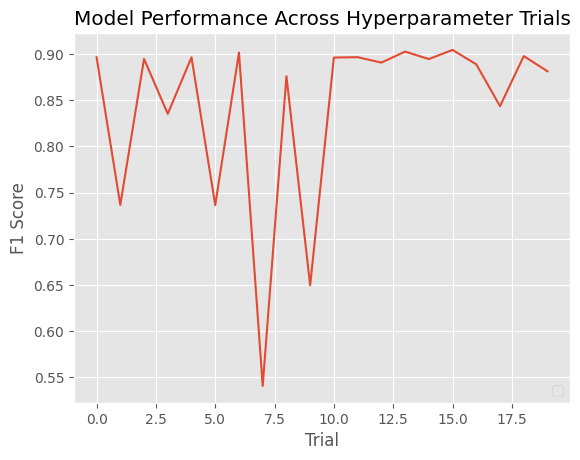

In [26]:
plt.style.use("ggplot")
plt.plot(study.trials_dataframe().value)  # plot the f1 scores of trials
plt.title("Model Performance Across Hyperparameter Trials")
plt.xlabel("Trial")
plt.ylabel("F1 Score")
plt.legend(loc="lower right")
plt.show()

### 3.3. Sonuçların Değerlendirilmesi
Eğitilmiş modelin performans metriklerinin ölçülmesi:

In [27]:
y_preds = model.predict(x_test_seq)
model_f1score = f1_score(y_test_seq, y_preds, average='macro')
print(f"F1 Score of the Model: {(model_f1score*100):.2f}%")

F1 Score of the Model: 91.39%


Confusion Matrix'in incelenmesi:

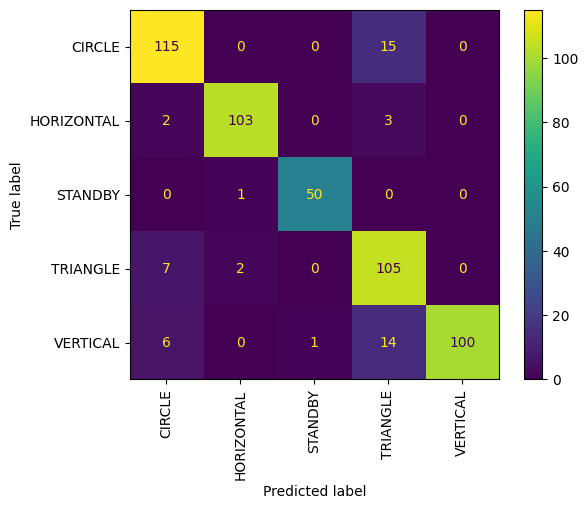

In [28]:
# plotting the confusion matrix
plt.style.use("default")
y_pred_named = np.vectorize(classes.get)(y_preds)
y_test_named = np.vectorize(classes.get)(y_test_seq)
ConfusionMatrixDisplay.from_predictions(y_test_named, y_pred_named)
plt.xticks(rotation=90)
plt.show()

## 4. Eğitilmiş Modelin Dışa Aktarımı
Geliştirme ortamı belleğinde tutulan yapay zeka modelinin (mimari + öğrenilmiş parametreler) çözüme dönüştürülmesi için statik bir dosya halinde saklanması gerekmektedir.

In [31]:
def convert_tree(input_model, output_path):
    # save the converted model
    edge_model = emlearn.convert(input_model, 
                                 method='inline', 
                                 dtype='int'
                                 )
    # create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    # save the model to a header file
    edge_model.save(
        file=os.path.join(output_path, 'model.h'), 
        name='model'
        )

In [32]:
convert_tree(model, output_path="./Models")

*Models klasöründe **Tiremo_model.h** ismiyle kaydettiğimiz dosyayı bilgisayarınıza indirin ve Tiremo®Cortex üzerinde çalıştıracağınız uygulama içerisinde kullanmak üzere hazır bulundurun.*

## 5. Eğitilen Model İle Uçta Yapay Zeka Çözümü
_Eğitilen modelin Tiremo®Cortex üzerinde çözüm olarak dağıtılması adımı için Tiremo®Intelligence kapsamında geliştirilen proje adımlarıyla devam ediniz._